<a href="https://colab.research.google.com/github/cchan555/final-project/blob/main/Google%20Colab%20Notebooks/ChanFinal_ProjectMay12026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Sentiment Analysis and Machine Learning
Cody Chan <br>

Dataset: Airline Reviews <br>
Methods: Sentiment Analysis with Machine Learning <br>
My Objective: Run Sentiment Analysis on the AirlineReviews.csv dataset.

## Summary of Dataset
For this dataset me and Jackson chose goes over may differnt types of Aircrafts and Airline Names that include rating and reviews from people who have flone with them. <br>

The dataset contains over 10,000 entries that can be used for our analysis. Later on in the analysis, shorten the dataset might be nessessary to get a smoother analysis. Columns in the dataset that can be used as pre labeling seniment analysis would be the "Recommended" column that has yes/no answers. The rating columns can include OverallScore, ServiceRating, SeatComfortRating, and many more for the corelation analysis. To get a more indept analysis, using the Airline name and CabinType would be usefull. <br>

For the inital analysis, the dataset it best for sentiment analysis because the airline reviews are usually expressed through positive and negative reviews in terms of the service quality. This allows for easier pattern detection and analysis.

In [1]:
# Installing Requried Packages
!pip install vaderSentiment # sentiment analysis tool
!pip install altair # Package for interactive charts and graphs

# Import libraries
import pandas as pd # Data manipulation
import numpy as np # Numerical computing and array operation
import matplotlib.pyplot as plt # Visuals
import seaborn as sns # More visuals
import altair as alt # Interactive interface
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load in the dataset
import requests # HTTP request for downloading URL
import io # input/output

%matplotlib inline

# Load in dataset from GitHUb
url = "https://media.githubusercontent.com/media/cchan555/final-project/refs/heads/main/Dataset%20Files/AirlineReviews.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text # Extract test from response

df = pd.read_csv(url) # Read CSV file

# Display basic information
print(df.head()) # First 5 rows
print(df.shape) # Print the number of rows and columns

print("\nColumn names and Dataset info:")
print(df.info())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00
        Aircraft    AirlineName      CabinType      DateFlown  \
0            NaN    AB Aviation  Economy Class  November 2019   
1           E120    AB Aviation  Economy Class      June 2019   
2  Embraer E120     AB Aviation  Economy Class      June 2019   
3            NaN  Aerocaribbean  Economy Class            NaN   
4            NaN  Aerocaribbean            NaN            NaN   

              DatePub  EntertainmentRating  FoodRating  GroundServiceRating  \
0  11th November 2019                    0           4                    4   
1      25th June 2019                    0           1                    1   
2      25th June 2019                    0           1                    1   
3  31st December 2010                    0           0                    0   
4  25th November 2010                    0           0                    0   

   OriginCountry  OverallScore  ...                Rou

## Interpretation of Dataset
Size: 129,445 airline reviews with 22 columns <br>
Column Details: <br>
*   Review Column: 128,631 non null customer reviews (What we will use for sentiment analysis)
*   Recommended Column: 129,455 non null columns showing yes/no indications if passenger recommends the airline (target variable)
*  AirlineName Column: 129,455 non null columns showing which Airline the review is about
*  CabinType Column: 126,437 non null columns showing Economy, Business, or First Class seats
*  OverallScore Column: 125,124 non null columns showing a numerical number for the rating given by each passenger
*  ServiceRating, SeatComfortRating, FoodRating, etc: Other numerical values that can be analyzed in terms of the rating

In the dataset, there are some missing values in some columns, so later, there will need to be some modificaitons before running Sentiment Analysis.


In [2]:
# Date Preprocessing
# Fill missing values in Review w/ empty string
df['Review'] = df['Review'].fillna('')

# Display final dataset dimensions
print(f"Dataset shape: {df.shape}")
# Total number of reviews
print(f"Number of reviews to analyze: {len(df)}")

Dataset shape: (129455, 22)
Number of reviews to analyze: 129455


## Sentiment Analysis

In [3]:
# Sentiment Analysis (Lab 7 information)
# Initialize sentiment analysis
analysis = SentimentIntensityAnalyzer()

# Calculate sentiment scores for each review
sentiment_scores = [analysis.polarity_scores(review) for review in df['Review']]

# Convert to DataFrame
sentiment_df = pd.DataFrame(sentiment_scores)

# Merge sentiment scores with original dataset using index (avoid duplication)
df = df.reset_index(drop=True)
sentiment_df = sentiment_df.reset_index(drop=True)
df_with_sentiment = pd.concat([df, sentiment_df], axis=1)

print("First 5 rows with sentiment scores:")
print(df_with_sentiment[['Review', 'Recommended', 'neg', 'neu', 'pos', 'compound']].head())

First 5 rows with sentiment scores:
                                              Review Recommended    neg  \
0  Moroni to Moheli. Turned out to be a pretty de...         yes  0.000   
1  Moroni to Anjouan. It is a very small airline....          no  0.083   
2  Anjouan to Dzaoudzi. A very small airline and ...          no  0.061   
3  Havana - Cayo Coco return. A one hour flight w...         yes  0.043   
4  Holguin to Havana last week. Okay apart from i...          no  0.096   

     neu    pos  compound  
0  0.800  0.200    0.9192  
1  0.890  0.028   -0.7869  
2  0.860  0.079    0.3298  
3  0.799  0.157    0.5058  
4  0.869  0.035   -0.5106  


### Interpretation of Sentiment Analysis
What does each Sentiment Score mean?
*   Neg: Range 0 to 1 (Ex. Terrble Service)
*   Pos: Range 0 to 1 (Ex. Excellent experience)
*   Neu: Range 0 to 1 (Ex. Flight depart on time - majority should be high)
*   Compound: This is the overall Sentiment weight ranging from negative 1 to positive 1. This is the main number that will be used for analysis. If the compound is greater than 0.05, it is considered a positive sentiment. If the compound is less than 0.05, it is considerd a negative sentiment. If it is between -0.05 and 0.05, it will be considered a neutral sentiment.

For example, if someone has a sentiment score of 0.72, it would be a strong positive and the passenger would likely recommend the airline. More positive reviews compared to negative reviews.




In [4]:
# Descriptive statistics for sentiment scores
# Using groupby and describe for analysis
print("Sentiment Score Statistics by Recommendation Status:")
print(df_with_sentiment.groupby('Recommended')[['neg', 'neu', 'pos', 'compound']].describe())

Sentiment Score Statistics by Recommendation Status:
                 neg                                                       \
               count      mean       std  min    25%    50%    75%    max   
Recommended                                                                 
no           77597.0  0.101351  0.057326  0.0  0.062  0.093  0.131  0.565   
yes          51858.0  0.039174  0.038691  0.0  0.000  0.032  0.060  0.410   

                 neu            ...    pos        compound            \
               count      mean  ...    75%    max    count      mean   
Recommended                     ...                                    
no           77597.0  0.834331  ...  0.080  0.520  77597.0 -0.361051   
yes          51858.0  0.780596  ...  0.227  0.644  51858.0  0.738329   

                                                               
                  std     min     25%     50%     75%     max  
Recommended                                                    
no      

In [5]:
# Calculate mean sentiment by recommendation for visualization
mean_sentiment = df_with_sentiment.groupby('Recommended')[['neg', 'neu', 'pos', 'compound']].mean()
print("Mean Sentiment Scores by Recommendation:")
print(mean_sentiment)

Mean Sentiment Scores by Recommendation:
                  neg       neu       pos  compound
Recommended                                        
no           0.101351  0.834331  0.056742 -0.361051
yes          0.039174  0.780596  0.175682  0.738329


## Statistics Relationship
Mean Compound Score Comparision:
*   Yes - compound value positive
*   No - compound value negative

There is a distict difference between the Sentiment score for those who answer yes and who answer no.

## Interpretation of Mean Sentiment Score
Those who answer yes:
*   Higher positive score means more positive words were used in the reviews
*   Lower negative score means fewer negative words and complaints
*   Overall compound score is high positives
This means most people who recommend a partictular airline have overall satisfaction and is expressed through positive words.

Those who answer no:
*   Higher negative score meaning there are more negative words and critics.
*   Lower positive score means less compliments.
*   Overall compound score meaning the overall negative sentiment
This means that people who do not recommend a particular airline express dissatisfaction

This analysis proves that the Sentiment Analysis is working and it validates the correct recommendations.





# Visualization for Sentiment Analysis

## Visualization 1: Bar Chart
This bar chart shows the average comparision of sentiment between those who recommend the airlin and those who do not. <br>

There are two bars: one for yes and one for no. The height of the bar equals the average compound sentiment score. <br>

Passengers who recommend an airline have a sentiment score greater than 0, ranging between 0 to about 0.7 while those who do not recommend the airline range between about -0.37 to 0. There is a clear separation between recommended and not recommended reviews. This bar chart provides a visual that the sentiment analysis works in capturing the satisfactions.

<Axes: title={'center': 'Compound Sentiment Score'}, xlabel='Recommended', ylabel='Mean Compound Score'>

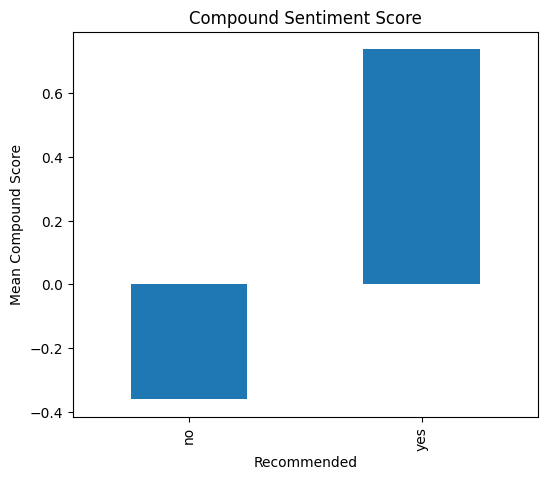

In [6]:
# Visualization 1: Bar chart of average sentiment by recommendation

# Generate mean of compound score by Recommendation
dfg = df_with_sentiment.groupby(['Recommended'])['compound'].mean()
# Create a bar plot
dfg.plot(kind='bar', title='Compound Sentiment Score', ylabel='Mean Compound Score',
         xlabel='Recommended', figsize=(6, 5))

## Visualization 2: Histogram of Sentiment Distribution
This shows how sentiment scores are distributed across all of the airline reviews <br>

Most airlines are clustered to the positive side to the right. The left side are the extreme negative reviews. The overall distribution shows that most passengers are satisfied but there are some who are not satisfied.

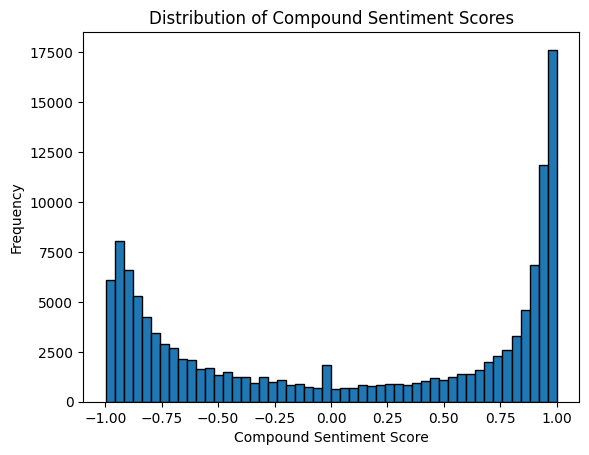

In [7]:
# Visualization 2: Histogram of compound sentiment scores

# Shows the distrubution of the scores
plt.hist(df_with_sentiment['compound'], bins=50, edgecolor='black')
plt.title('Distribution of Compound Sentiment Scores')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency') # Amount of times it happens
plt.show()

## Visualization 3: Bar Graph for Top 10 Airlines by Sentiment Score
This shows which airlines have the most positive reviews from passengers. <br>

For this graph, it includes airlines who have at least 30 reviews to keep reliability up. The bars show the average compound sentiment score for each airline. <br>
Initially when there was no filtering for at least 30 reviews, all of the reviews were high compound sentiment scores, meaning the top 10 airlines appeared to have the same score visually, which was not useful. Having at least 30 reviews makes it an reliable average.

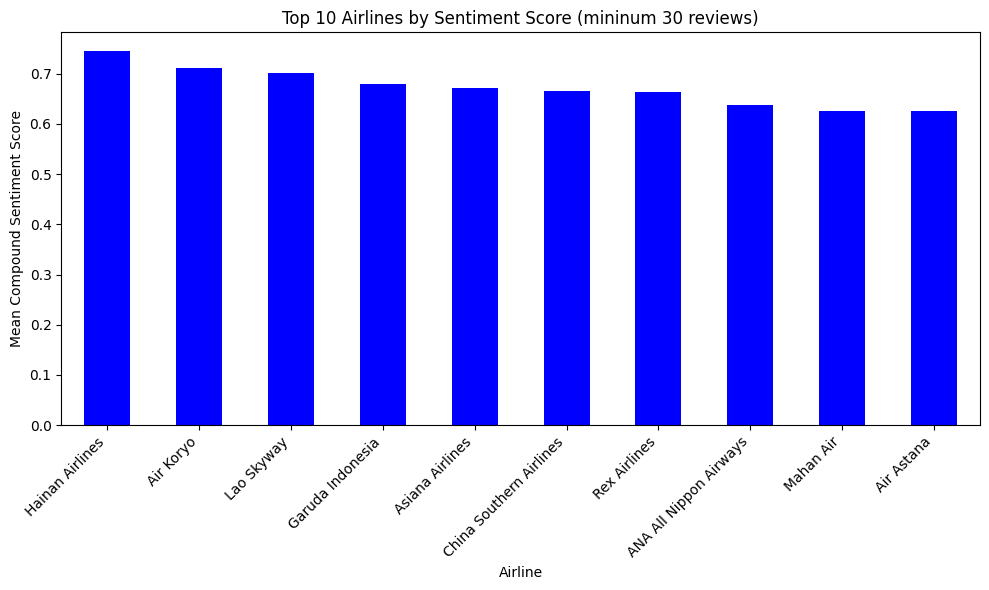

Top 10 Airlines by Sentiment (with at least 30 reviews):
Hainan Airlines: 0.745 (based on 402 reviews)
Air Koryo: 0.712 (based on 54 reviews)
Lao Skyway: 0.701 (based on 72 reviews)
Garuda Indonesia: 0.679 (based on 873 reviews)
Asiana Airlines: 0.672 (based on 497 reviews)
China Southern Airlines: 0.665 (based on 1970 reviews)
Rex Airlines: 0.663 (based on 44 reviews)
ANA All Nippon Airways: 0.638 (based on 557 reviews)
Mahan Air: 0.627 (based on 30 reviews)
Air Astana: 0.626 (based on 238 reviews)


In [8]:
# Visualization 3: Top 10 Airlines by Average Sentiment
# Shows which airlines has the best/worst sentiment scores

# Count reviews per airline
airline_counts = df_with_sentiment['AirlineName'].value_counts()

# Filter to airlines with at least 30 reviews
min_reviews = 30
airlines_with_enough_reviews = airline_counts[airline_counts >= min_reviews].index

# Filter dataset to airlines the meed the requirement
df_filtered = df_with_sentiment[df_with_sentiment['AirlineName'].isin(airlines_with_enough_reviews)]

# Calculate mean sentiment by airline and get top 10
airline_sentiment = df_filtered.groupby('AirlineName')['compound'].mean().sort_values(ascending=False)

# Get top 10 airlines
top_10_airlines = airline_sentiment.head(10)

# Create bar plot
top_10_airlines.plot(kind='bar', title=f'Top 10 Airlines by Sentiment Score (mininum {min_reviews} reviews)',
                      ylabel='Mean Compound Sentiment Score',
                      xlabel='Airline', figsize=(10, 6), color='blue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print out the number of reviews per airline
print(f"Top 10 Airlines by Sentiment (with at least {min_reviews} reviews):")
for airline, score in top_10_airlines.items():
    count = airline_counts[airline]
    print(f"{airline}: {score:.3f} (based on {count} reviews)")

## Visualization 4: Boxplot for Sentiment by Cabin Class
This graph provides insight to see if the type of seat has an affect on passenger sentiment score. <br>
The boxplot shows each cabin and how the distrinution of the seniment scores are. The line on the box shows the median of the sentiment score and the notch shows the confidence interval around the median. <br>

Overall, the cabin class does not have much of a affect on the review sentiment. Economy and Premium have a similar spread except Premium have a high median compared to economy. Business and first class also have a overlap in the overall spread of the sentiment score and the median is generally the same. So there is no affect between those two classes. The class that stands out the most out of the 4 classes would be the business class, as the overall spread is towards the top and the median is a little higher compared to first class.


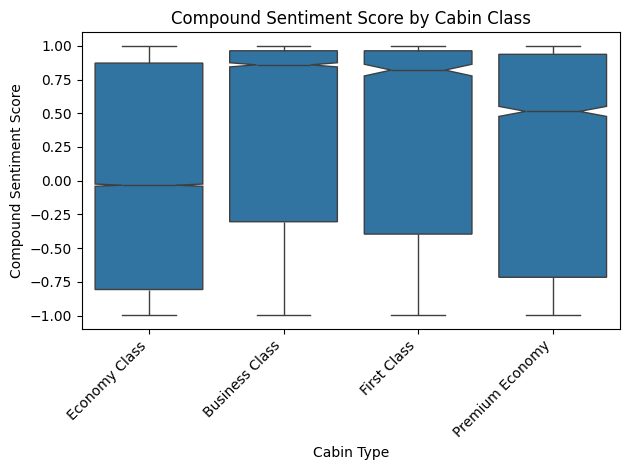


Mean Sentiment by Cabin Class:
CabinType
Business Class     0.402402
First Class        0.357946
Premium Economy    0.177070
Economy Class      0.009920
Name: compound, dtype: float64


In [9]:
# Visualization 4: Sentiment by Cabin Class
# Shows if cabin type (Economy, Business, First, Premium) affects sentiment

import seaborn as sns
# Create seaborn boxplots by cabin type
sns.boxplot(x='CabinType', y='compound', notch = True,
            data=df_with_sentiment, showfliers=False).set(title='Compound Sentiment Score by Cabin Class')
# Codify axis labels
plt.xlabel('Cabin Type')
plt.ylabel('Compound Sentiment Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print mean sentiment by cabin class
print("\nMean Sentiment by Cabin Class:")
print(df_with_sentiment.groupby('CabinType')['compound'].mean().sort_values(ascending=False))

# Machine Learning

Purpose: To predict airline recommendations from the reviews. Train and compare different classification algorithms to see which performs best.

In [10]:
# Load in the datasets
!pip install scikit-learn

# Import Libraries
import requests
import io
import pandas as pd
from sklearn.model_selection import train_test_split # For Selection and split
from sklearn.feature_extraction.text import CountVectorizer # Convert text to word frequency count
from sklearn.feature_extraction.text import TfidfTransformer # TF-IDF
from sklearn.pipeline import Pipeline # combine multiple steps together

from sklearn.naive_bayes import MultinomialNB # Bayes classifier
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.svm import LinearSVC # Vector Machine Classifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier # Decision tree

# Classification report (Precision, recall, f1-score)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

## What the Machine Learning will do?
Right now, the input of the data inclues the review text and the output of that would be the recommendations (yes/no). The end goal of this is to automatically predict the customer satisfaction from the review text. <br>

The three classifiers that will be used are the Naive Bayes, Logistic Regression, and the Random Forest.

In [11]:
# Prepare data for Machine Learning

# Select text and labels (features and target like lab 4)
X = df_with_sentiment['Review']
y = df_with_sentiment['Recommended']

# Split dataset into train and test sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Show the results of the split
print(f"Training set has {len(X_train)} samples.")
print(f"Testing set has {len(X_test)} samples.")

Training set has 90618 samples.
Testing set has 38837 samples.


The purpose of the training and testing split of the dataset is to prevent overfitting of the dataset. Using a 70/30 split allows enough data for the model to learn patterns while having a large enough sample to see the performance.

In [12]:
# Text preprocessing using CountVectorizer and TF-IDF
from sklearn.pipeline import Pipeline

# Build preprocessing pipeline
preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

# Fit pipeline on training data and transform it
print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

# Only transform test data
print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Preprocessing training data...
Preprocessing test data...


Text Preprocessing for Machine Learning: <br>
CounterCectorizer - Converts the text to a word frequency matrix and creates unique words. <br>
TF-IDF - Weights the importance of a word. Common words get a lower weight (like "the"), and stronger words get higher weight (like "excellent", "terrible").

In [13]:
# Train three classifiers of choice using training data

# Classifier 1: Naive Bayes
nb_classifier = MultinomialNB()
print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)
nb_predictions = nb_classifier.predict(test_preprocessed)

# Classifier 2: Logistic Regression
lr_classifier = LogisticRegression(max_iter=1000)
print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)
lr_predictions = lr_classifier.predict(test_preprocessed)

# Classifier 3: Random Forest
rf_classifier = RandomForestClassifier()
print("Training Random Forest classifier...")
rf_classifier.fit(train_preprocessed, y_train)
rf_predictions = rf_classifier.predict(test_preprocessed)

# Finding all 3 classifiers using accuracy
print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("RF Accuracy:", np.mean(rf_predictions == y_test))

Training Naive Bayes classifier...
Training Logistic Regression classifier...
Training Random Forest classifier...
NB Accuracy: 0.8593351700697788
LR Accuracy: 0.9189690243839638
RF Accuracy: 0.8776167057187734


## Interpretation

This section shows us how accurate the models are for predictions. Overall, anything above 80% is acceptable but there is still room for improvements. If it is above 85%, the accuract is good for most cases. If the accuracy is above 90%, it is the most reliable model to use. <br>

Based on the model for this dataset, it can be observed the following:
*   Naive Bayes: 85.93%
*   Logistic Regression: 91.90%
*   Random Forest: 87.52%



In [14]:
# Detailed evaluation
target_names = ['no', 'yes']
print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, rf_predictions, target_names=target_names))

              precision    recall  f1-score   support

          no       0.87      0.90      0.88     23349
         yes       0.84      0.80      0.82     15488

    accuracy                           0.86     38837
   macro avg       0.86      0.85      0.85     38837
weighted avg       0.86      0.86      0.86     38837

              precision    recall  f1-score   support

          no       0.93      0.94      0.93     23349
         yes       0.91      0.89      0.90     15488

    accuracy                           0.92     38837
   macro avg       0.92      0.91      0.92     38837
weighted avg       0.92      0.92      0.92     38837

              precision    recall  f1-score   support

          no       0.88      0.92      0.90     23349
         yes       0.87      0.81      0.84     15488

    accuracy                           0.88     38837
   macro avg       0.88      0.87      0.87     38837
weighted avg       0.88      0.88      0.88     38837



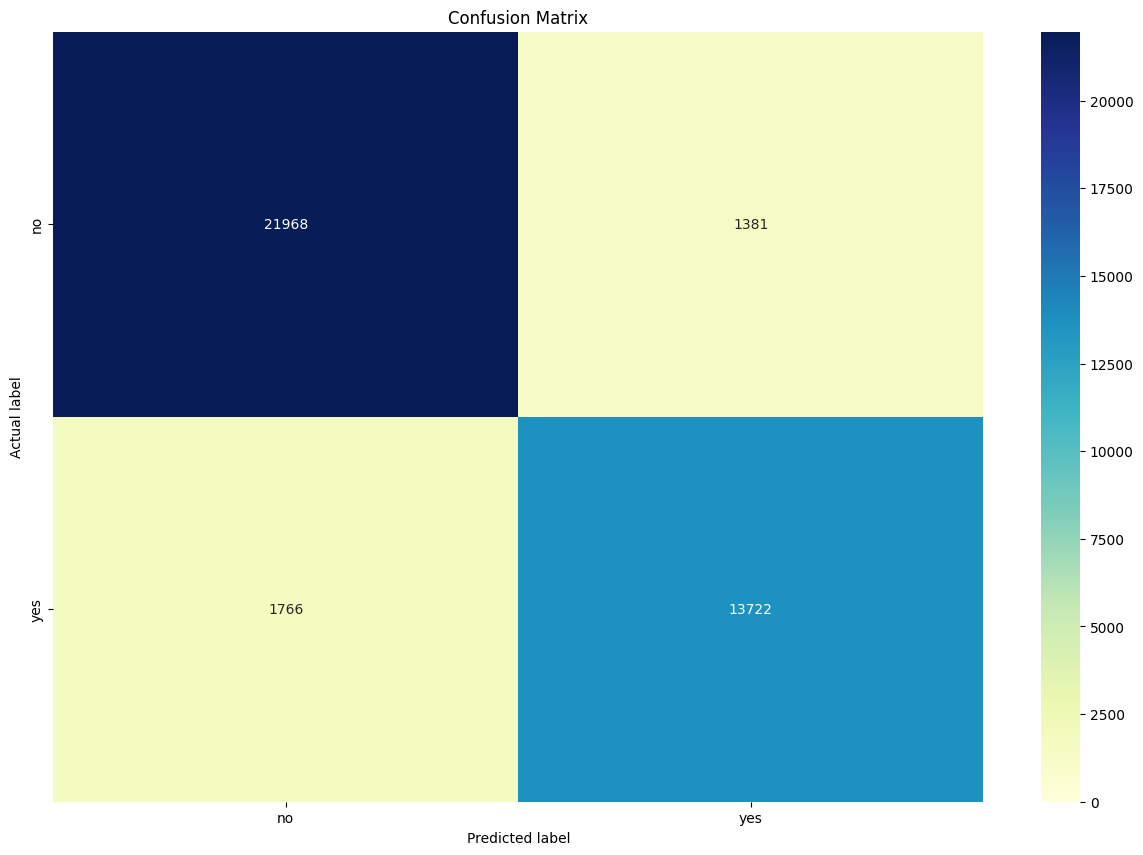

In [15]:
# Confusion Matrix
import seaborn as sn

# Select best classifier based on accuracy
best_prediction = lr_predictions
best_classifier = lr_classifier

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, best_prediction)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index = ['no', 'yes'],
    columns = ['no', 'yes'])
plt.figure(figsize=(15, 10))
x = sn.heatmap(
    conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(),
    fmt='d', cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

## Interpretation

Based on the Confusion Matrix, it can be see as the following: <br>
Note: (Predicted Label, Actual Label)
*   (No, No) - True Negative: Correctly predicted No
*   (Yes, No) - False Positive: Predict yes but actually no
*   (No, Yes) - False Negative: Predict no, but actually yes
*   (Yes, Yes) - True Positive: Correctly predicted yes

So, following the pattern and format above, we can see the following:
*   Top Left - 21,968: True negative, so reviews were not recommended by the passenger. This model correctly predicted the not recommendations in this section.
*   Top right - 1,381: False positive, so reviews that were not recommended but the model predicted them incorrectly (false alarm).
*   Bottom Left - 1,766: False Negative, so reviews were recommended but the model predicted not recommended (false detection).
*   Bottom right - 13,722: True Positive, so the reviews were recommended and the model predicted them correctly.

For this model, it performed well becasue the large numbers are bigger (top left and bottom right), meaning the model predicted them correctly. The smaller numbers were the other diagonal (top right to bottom left), which would be considered the error. <br>





In [16]:
# Save predictions to CSV

# Create DataFrame with test data and predictions
predictions_df = df_with_sentiment.loc[X_test.index].copy()

# Add predictions to dataset
predictions_df['Predicted_Recommendation'] = best_prediction

# Display sample of predictions
print(predictions_df[['Review', 'Recommended', 'Predicted_Recommendation']].head(10))
print(f"\nTotal predictions: {len(predictions_df)}")

# Create and save DataFrame as CSV
predictions_df.to_csv('airline_predictions.csv', index=False)
print("\nPredictions saved to 'airline_predictions.csv'")

                                                   Review Recommended  \
59950   Geneva to Seattle via Keflavik. The last time ...          no   
43695   London Heathrow to Bangkok. Superb value for m...         yes   
28644   Our connecting flight from Belgrade to Vienna ...          no   
96169                                                              no   
83734   Recently flew from London to Casablanca return...          no   
64345   Jetstar are the same as any low cost airline i...          no   
128844  Luton to Dubai via Katowice. Booked with Wizz ...          no   
122826  Bangkok to Istanbul. Business Class was great....         yes   
53851                                                             yes   
69800   ✅ , |  Washington to Seoul Incheon. The Korean...          no   

       Predicted_Recommendation  
59950                        no  
43695                       yes  
28644                        no  
96169                        no  
83734                     